# 01 - Data Collection
Let's pull the historical data we need for BrassCast-AI. We will start from 2010 so all our assets overlap nicely.

In [6]:
import yfinance as yf
import pandas as pd
import os
import matplotlib.pyplot as plt

# Create directory for raw data if it doesn't exist
os.makedirs('../data/raw', exist_ok=True)

### Download the Assets
We are going to download the 5 core assets and save them directly to CSVs.

In [7]:
tickers = {
    'copper': 'HG=F',
    'zinc_proxy': 'HINDZINC.NS',
    'usdinr': 'USDINR=X',
    'crude': 'CL=F',
    'copx': 'COPX'
}

data_frames = {}
for name, ticker in tickers.items():
    print(f"Downloading {name} [{ticker}]...")
    df = yf.download(ticker, start='2010-01-01', progress=False)
    data_frames[name] = df
    
    # Save to CSV
    df.to_csv(f'../data/raw/{name}_raw.csv')
    print(f"  -> Saved {name} with shape: {df.shape}")

  -> Saved copper with shape: (4198, 5)
  -> Saved zinc_proxy with shape: (4125, 5)
  -> Saved usdinr with shape: (4347, 5)
  -> Saved crude with shape: (4198, 5)
  -> Saved copx with shape: (4125, 5)


### Quick Look at the Data
Let's check the first few rows of Copper to make sure it looks right.

In [8]:
data_frames['copper'].head()

Price,Close,High,Low,Open,Volume
Ticker,HG=F,HG=F,HG=F,HG=F,HG=F
Date,,,,,
2010-01-04,3.3880,3.4090,3.3530,3.3880,404
2010-01-05,3.3960,3.4110,3.3685,3.3960,242
2010-01-06,3.4775,3.4995,3.4335,3.4775,109
2010-01-07,3.4115,3.5235,3.4110,3.4995,326
2010-01-08,3.3880,3.4220,3.3800,3.3880,311


### The Big Question: What is the Landed Cost of Copper in ₹/kg?
We have COMEX copper in `cents per pound` and USD/INR exchange rate. Let's convert it so we can see actual Indian market prices.

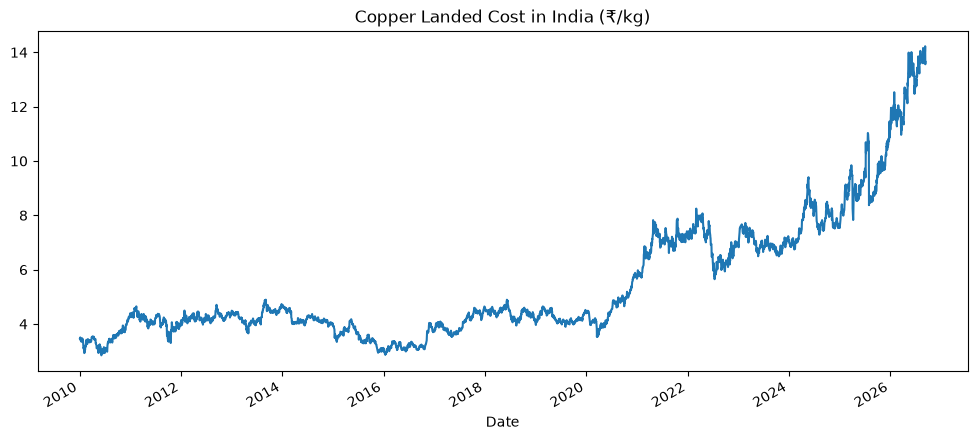

In [9]:


# 1. Grab just the raw price columns (using .iloc[:, 0] which means "first column")
copper_price = data_frames['copper']['Close'].iloc[:, 0]
usdinr_price = data_frames['usdinr']['Close'].iloc[:, 0]

# 2. Make the dates simple (removes the timezones)
copper_price.index = copper_price.index.tz_localize(None)
usdinr_price.index = usdinr_price.index.tz_localize(None)

# 3. Math
LB_TO_KG = 0.453592
copper_inr = (copper_price / 100 / LB_TO_KG) * usdinr_price

# 4. Plot
copper_inr.dropna().plot(figsize=(12, 5), title='Copper Landed Cost in India (₹/kg)')
plt.show()